Saving dataset.csv to dataset (1).csv
Shape: (303, 14)

Data Types:
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Missing Values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Summary Statistics:
               age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.00000

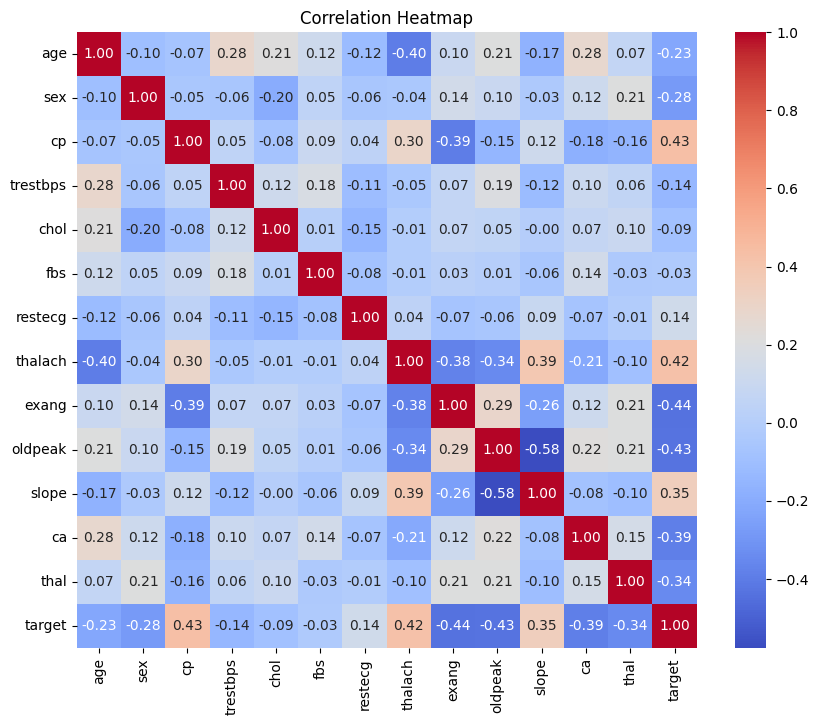

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

/tmp/ipython-input-2-1995853559.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


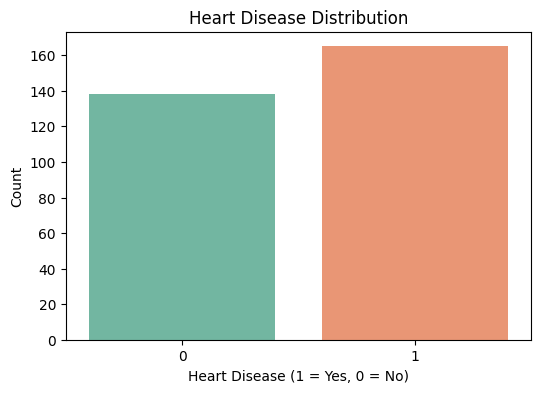

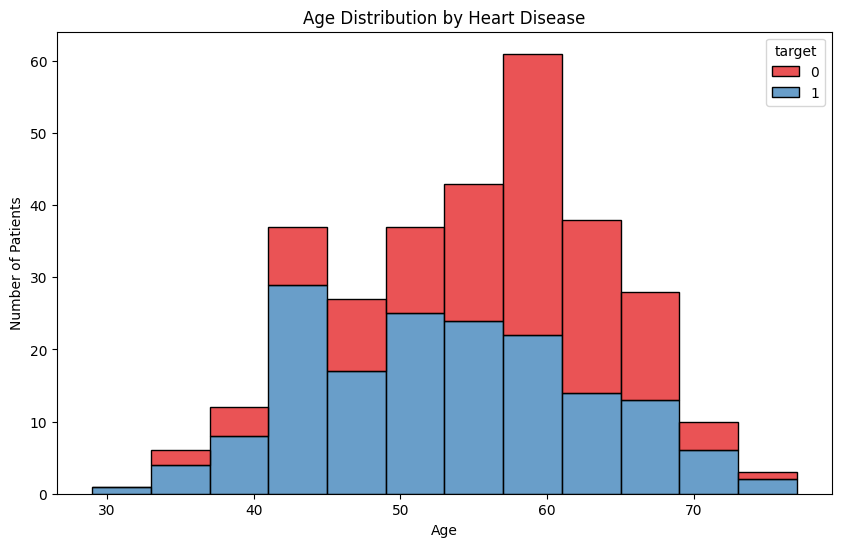

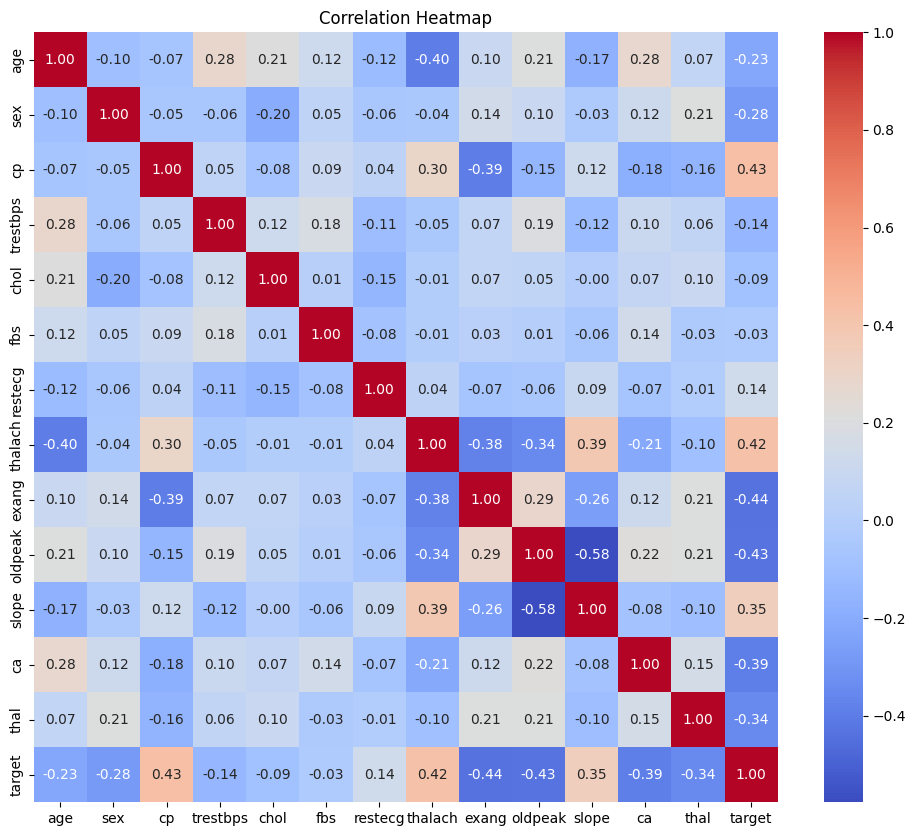


Confusion Matrix:
 [[28 13]
 [10 40]]
Accuracy Score: 0.7473

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.68      0.71        41
           1       0.75      0.80      0.78        50

    accuracy                           0.75        91
   macro avg       0.75      0.74      0.74        91
weighted avg       0.75      0.75      0.75        91



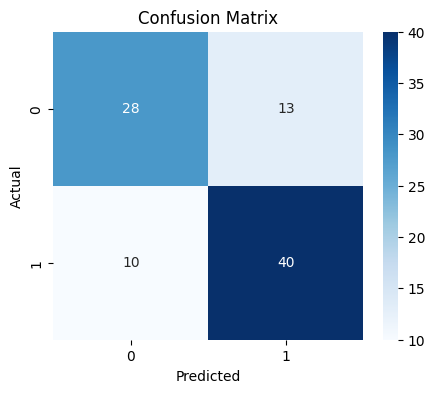

Decision Tree Accuracy: 0.7362637362637363
Confusion Matrix:
 [[32  9]
 [15 35]]


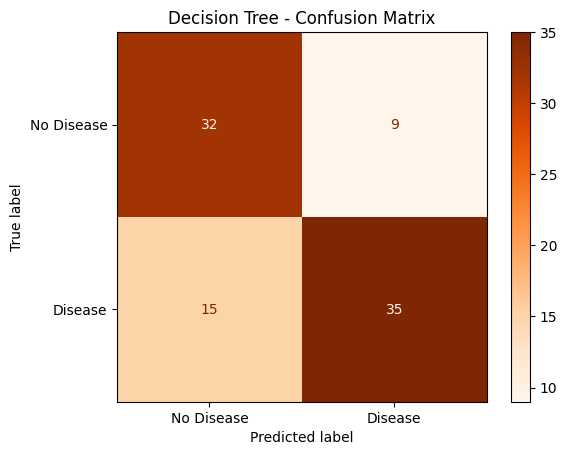

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73        41
           1       0.80      0.70      0.74        50

    accuracy                           0.74        91
   macro avg       0.74      0.74      0.74        91
weighted avg       0.74      0.74      0.74        91



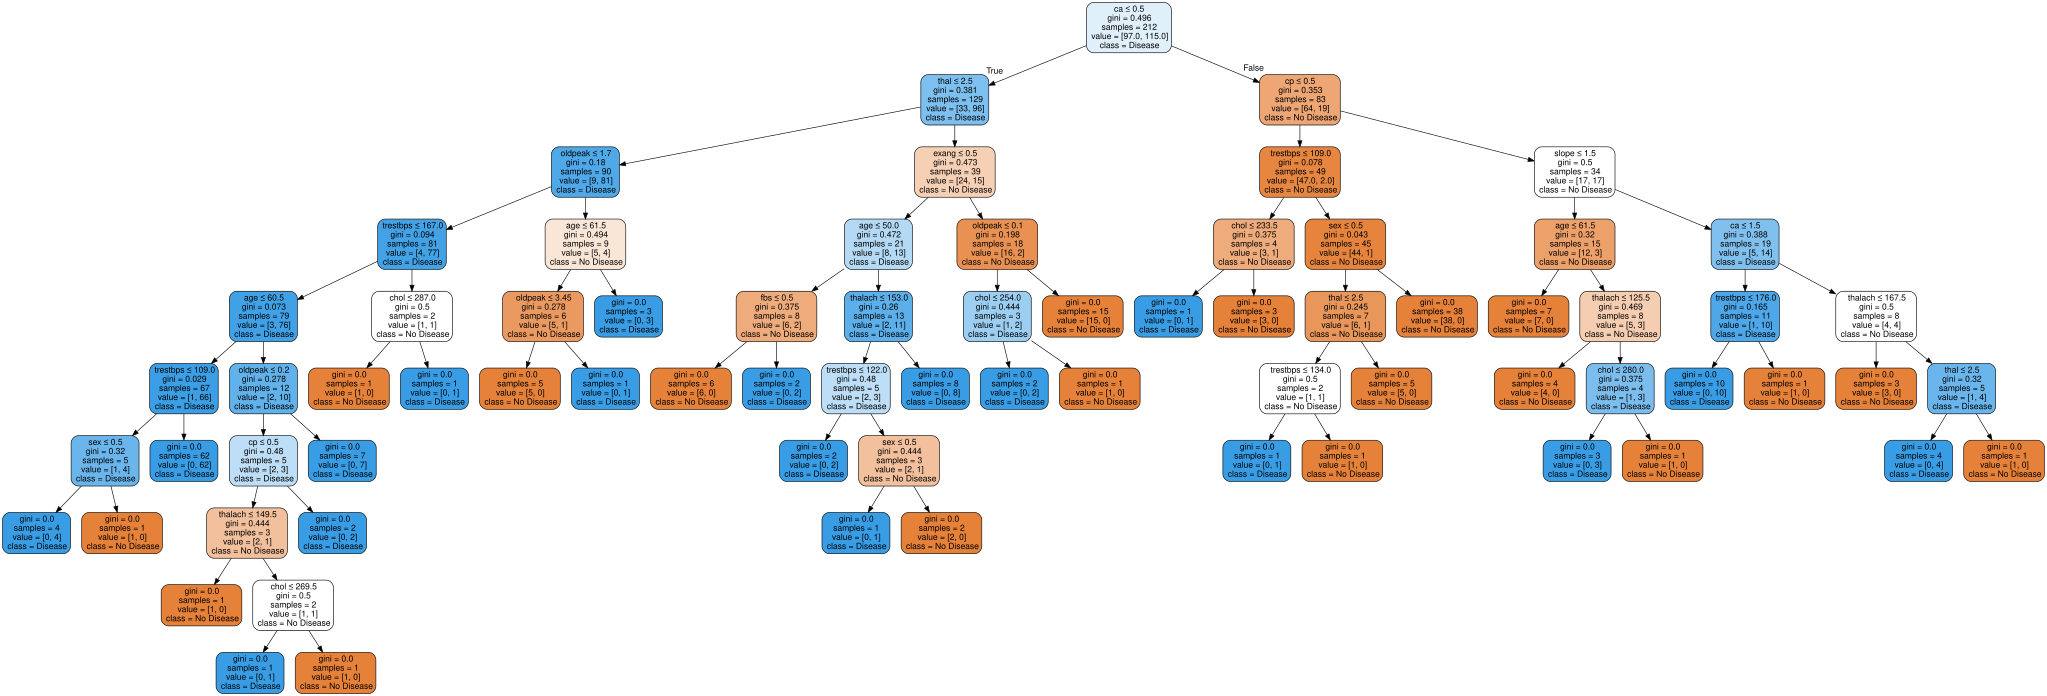


Logistic Regression Confusion Matrix:
[[28 13]
 [10 40]]
Logistic Regression Accuracy: 0.7473

Decision Tree Confusion Matrix:
[[30 11]
 [14 36]]
Decision Tree Accuracy: 0.7253

Random Forest Confusion Matrix:
[[30 11]
 [ 8 42]]
Random Forest Accuracy: 0.7912

Logistic Regression Classification Report:

              precision    recall  f1-score   support

           0       0.42      0.39      0.41        41
           1       0.53      0.56      0.54        50

    accuracy                           0.48        91
   macro avg       0.47      0.48      0.47        91
weighted avg       0.48      0.48      0.48        91


Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.41      0.40        41
           1       0.49      0.46      0.47        50

    accuracy                           0.44        91
   macro avg       0.44      0.44      0.44        91
weighted avg       0.44      0.44      0.44        91




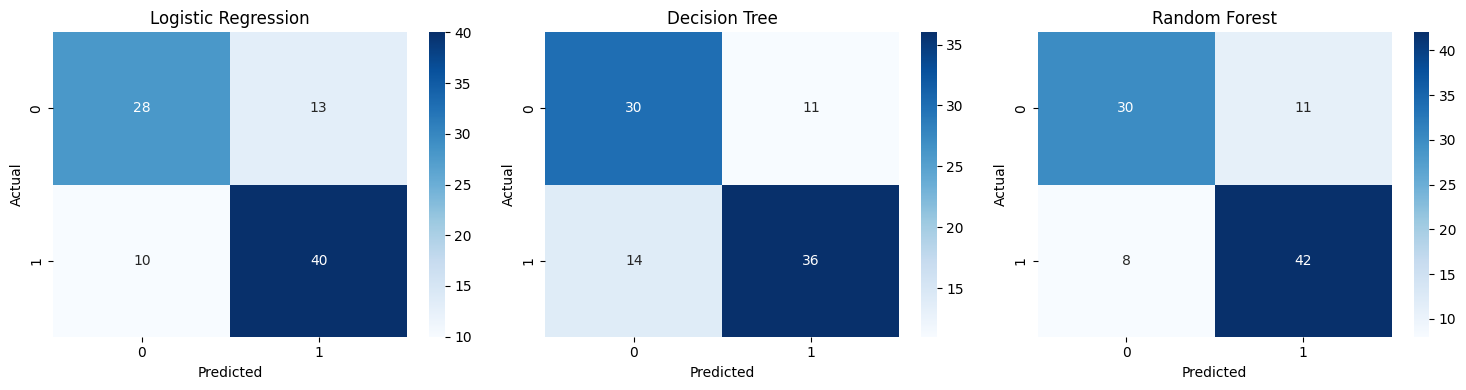


✅ Best Model: Random Forest with Accuracy: 0.791


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('dataset.csv')
df.columns = df.columns.str.strip().str.lower()
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n", correlation_matrix)
# Heatmap of correlation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
df = pd.read_csv('/content/dataset.csv')
print(df.head())
print(df.info())
# a. Patients with and without heart disease
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()
# b. Age vs Heart Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', multiple='stack', palette='Set1')
plt.title("Age Distribution by Heart Disease")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()
# c. Heatmap of Correlation
plt.figure(figsize=(12, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
X = df.drop('target', axis=1)
y = df['target']
# a.i. Split into 70:30 ratio
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# a.ii. Build and train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict
y_pred = model.predict(X_test)
# a.iii. Confusion matrix and accuracy
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
print("Accuracy Score:", round(acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
import graphviz
from sklearn.tree import export_graphviz
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv('/content/dataset.csv')
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_cm = confusion_matrix(y_test, dt_pred)
dt_acc = accuracy_score(y_test, dt_pred)
dot_data = export_graphviz(
    dt_model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("decision_tree", format="png", cleanup=True)
graph.view()
#  Build Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
#  Confusion Matrix & Accuracy
rf_cm = confusion_matrix(y_test, rf_pred)
rf_acc = accuracy_score(y_test, rf_pred)
estimator = rf_model.estimators_[0]
dot_data_rf = export_graphviz(
    estimator,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)
graph_rf = graphviz.Source(dot_data_rf)
graph_rf.render("random_forest_tree", format="png", cleanup=True)
graph_rf.view()
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_cm = confusion_matrix(y_test, log_pred)
log_acc = accuracy_score(y_test, log_pred)
models = {
    "Logistic Regression": (log_pred, log_cm, log_acc),
    "Decision Tree": (dt_pred, dt_cm, dt_acc),
    "Random Forest": (rf_pred, rf_cm, rf_acc)
}
X = df.drop("target", axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", acc_tree)
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix:\n", cm_tree)
ConfusionMatrixDisplay(cm_tree, display_labels=["No Disease", "Disease"]).plot(cmap="Oranges")
plt.title("Decision Tree - Confusion Matrix")
plt.show()
print("Classification Report:\n", classification_report(y_test, y_pred_tree))

dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree_heart", format='png', cleanup=True)
display(graph)
#  Print Confusion Matrices
for name, (_, cm, acc) in models.items():
    print(f"\n{name} Confusion Matrix:\n{cm}")
    print(f"{name} Accuracy: {round(acc, 4)}")
#  Print Classification Reports
for name, (pred, _, _) in models.items():
    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_test, pred))
print("\nModel Metrics Summary:")
for name, (pred, _, acc) in models.items():
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    print(f"{name}: Accuracy={round(acc, 3)}, Precision={round(precision, 3)}, Recall={round(recall, 3)}, F1 Score={round(f1, 3)}")
# Visualize all confusion matrices
plt.figure(figsize=(15, 4))
for i, (name, (_, cm, _)) in enumerate(models.items()):
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# e. Select best model based on accuracy
best_model = max(models.items(), key=lambda x: x[1][2])
print(f"\n✅ Best Model: {best_model[0]} with Accuracy: {round(best_model[1][2], 3)}")